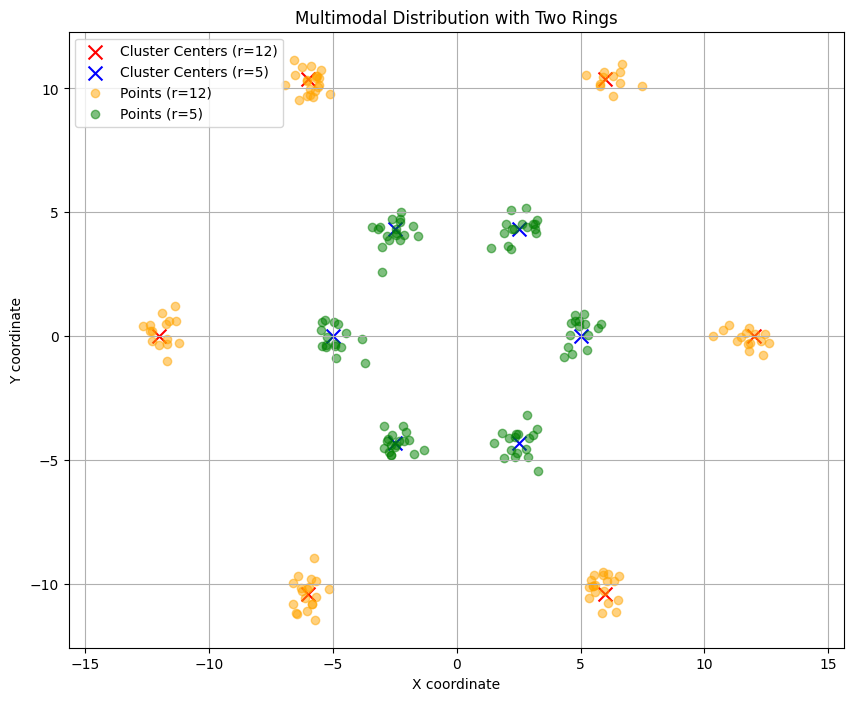

In [1]:
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm
def GenerateDataset(datasetSize, standardDeviation, clusterCenters):
    dataset = []
    for i in range(datasetSize):
        #Generate random 2D points 
        sample = np.random.randn(clusterCenters.shape[1]) * standardDeviation
        #Choose a random cluster center
        currentClusterCenter = random.randint(0, len(clusterCenters) - 1) 
        #Add noise to the cluster center
        sample[0] += clusterCenters[currentClusterCenter, 0]
        sample[1] += clusterCenters[currentClusterCenter, 1]
        dataset.append(sample)
    return np.array(dataset)

def GenerateClusterCenters(anglesInRadians, clusterRadius):
    cluster = []
    for i in range(len(anglesInRadians)):
        points = np.array([clusterRadius * np.cos(anglesInRadians[i]), clusterRadius * np.sin(anglesInRadians[i])])
        cluster.append(points)
    return np.array(cluster)

datasetSize = 100
standardDeviation = 0.5
anglesInDegrees = np.array([0, 60, 120, 180, 240,  300])
anglesInRadians = np.deg2rad(anglesInDegrees)

clusterRadius0  = 12
clusterCenters0 = GenerateClusterCenters(anglesInRadians, clusterRadius0)

clusterRadius1  = 5
clusterCenters1 = GenerateClusterCenters(anglesInRadians, clusterRadius1)


points0 = GenerateDataset(datasetSize, standardDeviation, clusterCenters0)    
points1 = GenerateDataset(datasetSize, standardDeviation, clusterCenters1)    

# Plotting
plt.figure(figsize=(10, 8))
# Plot cluster centers
plt.scatter(clusterCenters0[:, 0], clusterCenters0[:, 1], c='red', s=100, marker='x', label='Cluster Centers (r=12)')
plt.scatter(clusterCenters1[:, 0], clusterCenters1[:, 1], c='blue', s=100, marker='x', label='Cluster Centers (r=5)')
# Plot generated points
plt.scatter(points0[:, 0], points0[:, 1], c='orange', alpha=0.5, label='Points (r=12)')
plt.scatter(points1[:, 0], points1[:, 1], c='green', alpha=0.5, label='Points (r=5)')
plt.title('Multimodal Distribution with Two Rings')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal')  # Important for circular distributions
plt.show()


In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, context_dim, h, out_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(in_dim + context_dim, h),
            nn.Tanh(),
            nn.Linear(h, h), 
            nn.Tanh(),
            nn.Linear(h, out_dim)
        )
        
    def forward(self, x, context):
        # Convert inputs to model's dtype if needed
        x = x.to(next(self.parameters()).dtype)
        context = context.to(next(self.parameters()).dtype)
        return self.network(torch.cat((x, context), dim=1))

class Dataset(torch.utils.data.Dataset):
    def __init__(self, dist1, dist2):
        self.dist1 = dist1
        self.dist2 = dist2
        assert self.dist1.shape == self.dist2.shape

    def __len__(self):
        return self.dist1.shape[0]

    def __getitem__(self, idx):
        return self.dist1[idx], self.dist2[idx]
    
def TrainRectifiedFlow(rectifiedFlow, optimizer, trainDataloader, NB_EPOCHS, eps=1e-15):
    for epoch in tqdm(range(NB_EPOCHS)):
        for z0, z1 in (trainDataloader):
            z0, z1 = z0.to(device), z1.to(device)
            t = torch.rand((z1.shape[0], 1), device=device)
            z_t = t * z1 + (1.-t) * z0
            target = z1 - z0

            pred = rectifiedFlow(z_t, t)
            loss = (target - pred).view(pred.shape[0], -1).abs().pow(2).sum(dim=1).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

def sample(rectifiedFlow, T, pi_0):
    samples = [pi_0.clone().unsqueeze(0)]
    for i in (range(T)):
        t = torch.ones((pi_0.shape[0], 1), device=samples[-1].device) * i / T
        drift_pred = rectifiedFlow(samples[-1].squeeze(0), t)
        samples.append((samples[-1] + drift_pred * 1. / T))
    return torch.cat(samples)


100%|██████████| 1500/1500 [00:08<00:00, 183.24it/s]


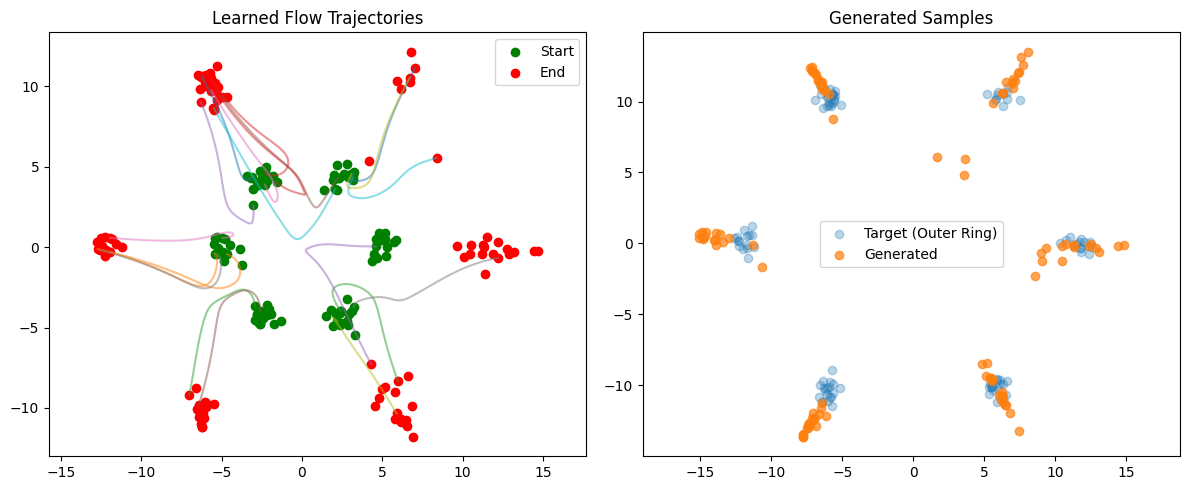

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dist0 = torch.tensor(points1, dtype=torch.float32)  # inner ring (source)
dist1 = torch.tensor(points0, dtype=torch.float32)  # outer ring (target)

trainLoader = DataLoader(Dataset(dist0, dist1), batch_size=64, shuffle=True)
rectifiedFlow = MLP(in_dim=2, context_dim=1, h=128, out_dim=2).to(device)
optimizer = torch.optim.Adam(rectifiedFlow.parameters(), lr=1e-3)
TrainRectifiedFlow(rectifiedFlow, optimizer, trainLoader, NB_EPOCHS=1500)

trajectory = sample(rectifiedFlow, T=100, pi_0=dist0.to(device))
traj = trajectory.detach().cpu().numpy()
finalSamples = traj[-1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(min(20, traj.shape[1])):
    plt.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.5)
plt.scatter(traj[0, :, 0], traj[0, :, 1], c='green', label='Start')
plt.scatter(traj[-1, :, 0], traj[-1, :, 1], c='red', label='End')
plt.title("Learned Flow Trajectories")
plt.axis('equal')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(points0[:, 0], points0[:, 1], alpha=0.3, label='Target (Outer Ring)')
plt.scatter(final_samples[:, 0], final_samples[:, 1], alpha=0.7, label='Generated')
plt.title("Generated Samples")
plt.axis('equal')
plt.legend()

plt.tight_layout()
plt.show()